# LLM Evaluation — IHMU (juiz LLM)

Roda um LLM como **juiz** sobre respostas existentes em `llm_prompt_results`, classificando cada uma em I/H/M/U conforme o codebook em [prompts/ihmu-classification-prompt-v01.txt](../../prompts/ihmu-classification-prompt-v01.txt).

O juiz é representado no Label Studio por um usuário dedicado (criado por este notebook), e suas anotações entram em `evaluation_labels` exatamente como as de um humano — habilitando concordância (Cohen's κ) com humanos sob o mesmo schema. Discriminação humano × juiz vem da própria constraint `UNIQUE (llm_result_id, smell_occurrence_id, annotator)`.

**Dois modos de escopo (flag `RESTRICT_TO_HUMAN_LABELED` na célula de configuração):**

- `RESTRICT_TO_HUMAN_LABELED = True` (default): o juiz avalia **apenas os pares já rotulados por outro anotador** em `evaluation_labels` e que ainda não foram rotulados por ele. Usa `fetch_pairs_already_labeled_by_other_annotators(...)`. É o caminho para calcular κ humano × juiz exatamente sobre o conjunto que o humano avaliou.
- `RESTRICT_TO_HUMAN_LABELED = False` (scale-up): o juiz avalia **todos** os pares elegíveis em `llm_prompt_results` (success=TRUE, smell e severidade no escopo) que ainda não foram rotulados por ele, independente de existir rótulo humano. Usa `fetch_unlabeled_pairs(...)`.

Em ambos os modos a query é parametrizada pelo email do juiz, então uma reexecução só processa o que falta — idempotente.

Fluxo:
1. Setup (path + schema).
2. Conexão com o LS (reusa o projeto criado em `run_human_evaluation`).
3. Configuração do juiz (modelo, hiperparâmetros, escopo).
4. Template do prompt.
5. Garantir usuário-juiz no LS.
6. Garantir tasks no LS (idempotente).
7. Index local de tasks e pares já avaliados.
8. Loop de avaliação (chama OpenAI, parse, cria annotation).
9. Sync para `evaluation_labels`.
10. Verificação rápida e κ humano × juiz.

## 1. Setup

In [4]:
import sys
from pathlib import Path

_cwd = Path.cwd().resolve()
_project_root = None
for candidate in [_cwd, *_cwd.parents]:
    if (candidate / "integrations").exists() and (candidate / "managers").exists():
        _project_root = candidate
        break

if _project_root is None:
    raise RuntimeError(f"Could not locate project root from {_cwd}.")

if str(_project_root) not in sys.path:
    sys.path.insert(0, str(_project_root))
print("Project root:", _project_root)

Project root: /home/marcelo/Doutorado/llm-code-review-on-smells


In [5]:
import os

from start_here.experiments.constants import (
    LABEL_STUDIO_API_KEY,
    LABEL_STUDIO_LABEL_CONFIG_VERSION,
    LABEL_STUDIO_PROJECT_TITLE,
    LABEL_STUDIO_URL,
    OPENAI_API_KEY,
)

os.environ.setdefault("LABEL_STUDIO_URL", LABEL_STUDIO_URL)
if LABEL_STUDIO_API_KEY:
    os.environ.setdefault("LABEL_STUDIO_API_KEY", LABEL_STUDIO_API_KEY)
if OPENAI_API_KEY:
    os.environ.setdefault("OPENAI_API_KEY", OPENAI_API_KEY)

from database.experiment_log import (
    create_all_tables,
    fetch_pairs_already_labeled_by_other_annotators,
    fetch_unlabeled_pairs,
    get_or_create_judge_setup,
    insert_judge_call,
    upsert_evaluation_labels,
)
from integrations.label_studio import LabelStudioClient
from integrations.openai_llm_provider import OPENAI_MODELS, OpenAILLMProvider
from managers.evaluation_input_manager import (
    build_task_external_id,
    upload_responses_to_label_studio,
)

create_all_tables()
print("Schema garantido.")

Schema garantido.


## 2. Cliente do Label Studio

Recupera o projeto criado pelo `run_human_evaluation`. Se ainda não existir, ele é criado aqui com o mesmo `label_config` versionado.

In [3]:
client = LabelStudioClient()
current_user = client.whoami()
print("Conectado como:", getattr(current_user, "username", None) or getattr(current_user, "email", None))

project = client.get_or_create_project(
    title=LABEL_STUDIO_PROJECT_TITLE,
    label_config_version=LABEL_STUDIO_LABEL_CONFIG_VERSION,
)
PROJECT_ID = project.id
print(f"Projeto: id={PROJECT_ID}  ·  título={project.title}")

Conectado como: marcelogabrielfechine
Projeto: id=1  ·  título=LLM Code Review — IHMU


## 3. Configuração do juiz

- `JUDGE_MODEL_KEY` deve estar em `OPENAI_MODELS`.
- `JUDGE_ANNOTATOR_EMAIL` é o identificador do juiz em `evaluation_labels.annotator`. Padrão: `<model_key>@llm.eval`.
- `RESTRICT_TO_HUMAN_LABELED = True` restringe a execução aos pares que já estão em `evaluation_labels` por algum outro anotador (para κ humano × juiz no mesmo conjunto). `False` libera pra todo o backlog de `llm_prompt_results`.
- `EVAL_LIMIT` / `DEMO_ONLY` controlam o escopo adicional desta execução. Para avaliação total no modo scale-up, deixe ambos `None`.

In [7]:
JUDGE_MODEL_KEY = "openai_gpt-4.1"
JUDGE_TEMPERATURE = 0.0
JUDGE_TOP_P = 1.0
JUDGE_MAX_TOKENS = 2048

PROMPT_VERSION = "v04"
PROMPT_FILE = f"ihmu-classification-prompt-{PROMPT_VERSION}.txt"

RESTRICT_TO_HUMAN_LABELED = False   # True = só pares já em evaluation_labels por outros; False = todo llm_prompt_results
EVAL_LIMIT = None                  # None = sem corte de quantidade
DEMO_ONLY = None                   # None = sem filtro; True = só demo_set; False = exclui demo_set
UPLOAD_SHUFFLE_SEED = 42

if JUDGE_MODEL_KEY not in OPENAI_MODELS:
    raise ValueError(
        f"JUDGE_MODEL_KEY={JUDGE_MODEL_KEY!r} não está em OPENAI_MODELS. "
        f"Disponíveis: {list(OPENAI_MODELS.keys())}"
    )

JUDGE_ANNOTATOR_EMAIL = f"{JUDGE_MODEL_KEY}-{PROMPT_VERSION}@llm.eval"
JUDGE_USERNAME = f"{JUDGE_MODEL_KEY}-{PROMPT_VERSION}"
JUDGE_DISPLAY_NAME = f"{OPENAI_MODELS[JUDGE_MODEL_KEY]['model_name']} ({PROMPT_VERSION})"
JUDGE_EXPERIMENT_NAME = f"LLM Judge — IHMU {PROMPT_VERSION}"
print(f"Juiz: {JUDGE_ANNOTATOR_EMAIL}")
print(f"Modelo: {OPENAI_MODELS[JUDGE_MODEL_KEY]['description']}")
print(f"Prompt: {PROMPT_FILE}")
print(f"Modo: {'restrito a pares já rotulados por outros' if RESTRICT_TO_HUMAN_LABELED else 'todo o backlog de llm_prompt_results'}")

Juiz: openai_gpt-4.1-v04@llm.eval
Modelo: OpenAI GPT-4.1 - Latest model
Prompt: ihmu-classification-prompt-v04.txt
Modo: todo o backlog de llm_prompt_results


## 4. Template do prompt

Lê o arquivo e checa que todos os placeholders existem antes de começar a chamar o LLM — falhar aqui é muito mais barato que falhar no meio do batch.

In [8]:
PROMPT_TEMPLATE_PATH = _project_root / "prompts" / PROMPT_FILE
PROMPT_TEMPLATE = PROMPT_TEMPLATE_PATH.read_text(encoding="utf-8")

REQUIRED_PLACEHOLDERS = [
    "<code file>",
    "<code snippet>",
    "<code_name>",
    "<start_line>",
    "<end_line>",
    "<method | class>",
    "<Long Method | Feature Envy | Data Class>",
    "<major | critical>",
    "<llm response>",
]
missing_placeholders = [p for p in REQUIRED_PLACEHOLDERS if p not in PROMPT_TEMPLATE]
if missing_placeholders:
    raise ValueError(f"Placeholders ausentes em {PROMPT_FILE}: {missing_placeholders}")

print(f"Template carregado: {PROMPT_FILE} ({len(PROMPT_TEMPLATE)} chars)")

Template carregado: ihmu-classification-prompt-v04.txt (16128 chars)


## 5. Garantir usuário-juiz no Label Studio

Cria o usuário se ainda não existir. Idempotente. O `first_name`/`last_name` controlam o nome que aparece no header da annotation no UI do LS.

In [6]:
def get_or_create_judge_user(
    ls_client: LabelStudioClient,
    email: str,
    username: str,
    first_name: str,
    last_name: str,
):
    for existing in ls_client.sdk.users.list():
        if getattr(existing, "email", None) == email:
            return existing
    return ls_client.sdk.users.create(
        email=email,
        username=username,
        first_name=first_name,
        last_name=last_name,
    )

judge_user = get_or_create_judge_user(
    ls_client=client,
    email=JUDGE_ANNOTATOR_EMAIL,
    username=JUDGE_USERNAME,
    first_name="LLM Judge",
    last_name=JUDGE_DISPLAY_NAME,
)
JUDGE_USER_ID = judge_user.id
print(f"Usuário-juiz: id={JUDGE_USER_ID}  ·  email={JUDGE_ANNOTATOR_EMAIL}")

Usuário-juiz: id=5  ·  email=openai_gpt-4.1-v04@llm.eval


## 6. Garantir tasks no Label Studio

Sobe pro LS qualquer par elegível que ainda não esteja como task. Idempotente — dedup por `task_external_id`. Compartilha as mesmas tasks com o humano (mesmo projeto + mesmo `task_external_id`), então quando o humano rotular o par também, as duas annotations ficam lado a lado na mesma task.

In [7]:
uploaded = upload_responses_to_label_studio(
    client=client,
    project_id=PROJECT_ID,
    annotator=JUDGE_ANNOTATOR_EMAIL,
    label_config_version=LABEL_STUDIO_LABEL_CONFIG_VERSION,
    demo_only=DEMO_ONLY,
    limit=EVAL_LIMIT,
    shuffle_seed=UPLOAD_SHUFFLE_SEED,
)
print(f"Tasks subidas pro LS nesta execução: {uploaded}.")

skipping 444 pares já presentes no projeto LS
Tasks subidas pro LS nesta execução: 0.


## 7. Index local de tasks + pares já avaliados pelo juiz

Mapeia `task_external_id → ls_task_id` e identifica quais pares já têm annotation do juiz. Garante idempotência mesmo se o sync para `evaluation_labels` não tiver rodado ainda (o loop usa esse set pra não duplicar annotations no LS).

In [8]:
def extract_completed_by_id(annotation) -> int | None:
    if isinstance(annotation, dict):
        completed_by = annotation.get("completed_by")
    else:
        completed_by = getattr(annotation, "completed_by", None)
    if isinstance(completed_by, int):
        return completed_by
    if isinstance(completed_by, dict):
        return completed_by.get("id")
    if hasattr(completed_by, "id"):
        return completed_by.id
    return None

def is_cancelled(annotation) -> bool:
    if isinstance(annotation, dict):
        return bool(annotation.get("was_cancelled", False))
    return bool(getattr(annotation, "was_cancelled", False))

def index_tasks(ls_client: LabelStudioClient, project_id: int, judge_user_id: int):
    external_id_to_task_id: dict[str, int] = {}
    already_judged_external_ids: set[str] = set()
    for task in ls_client.list_tasks_with_annotations(project_id):
        data = getattr(task, "data", None)
        if not isinstance(data, dict):
            continue
        external_id = data.get("task_external_id")
        if not external_id:
            continue
        external_id_to_task_id[external_id] = task.id
        for annotation in getattr(task, "annotations", None) or []:
            if is_cancelled(annotation):
                continue
            if extract_completed_by_id(annotation) == judge_user_id:
                already_judged_external_ids.add(external_id)
                break
    return external_id_to_task_id, already_judged_external_ids

external_id_to_task_id, already_judged_external_ids = index_tasks(
    client, PROJECT_ID, JUDGE_USER_ID
)
print(f"Tasks no projeto: {len(external_id_to_task_id)}")
print(f"Já avaliadas pelo juiz: {len(already_judged_external_ids)}")

Tasks no projeto: 444
Já avaliadas pelo juiz: 438


## 8. Loop de avaliação

Para cada par ainda não avaliado: renderiza o prompt (5 substituições), chama o OpenAI, faz parse estrito de `CLASSIFICATION:` (I/H/M/U), monta o `result[]` no formato do `label_config v1` (`label` + `comment`) e cria a annotation via `client.sdk.annotations.create(id=ls_task_id, completed_by=JUDGE_USER_ID, ...)`.

**Fail-loud:** se o parse falhar, o loop para com `ValueError` carregando a resposta crua — sinaliza problema no prompt ou no modelo, e não vale continuar gastando tokens.

In [10]:
import re
import time
from datetime import datetime, timezone

CLASSIFICATION_RE = re.compile(
    r"CLASSIFICATION:\s*(INSTRUMENTAL|HELPFUL|MISLEADING|UNCERTAIN|[IHMU])\b",
    re.IGNORECASE,
)
REASONING_BLOCK_RE = re.compile(r"REASONING:.*", re.DOTALL)
_CLASSIFICATION_WORD_TO_LETTER = {
    "I": "I", "H": "H", "M": "M", "U": "U",
    "INSTRUMENTAL": "I", "HELPFUL": "H",
    "MISLEADING": "M", "UNCERTAIN": "U",
}

SMELL_DISPLAY = {
    "long method": "Long Method",
    "feature envy": "Feature Envy",
    "data class": "Data Class",
}

def render_prompt(template: str, pair: dict) -> str:
    return (
        template
        .replace("<code file>",    pair["file_content"] or "")
        .replace("<code snippet>", pair["code_snippet"] or "")
        .replace("<code_name>",    pair["code_name"] or "")
        .replace("<start_line>",   str(pair["start_line"]) if pair["start_line"] is not None else "")
        .replace("<end_line>",     str(pair["end_line"]) if pair["end_line"] is not None else "")
        .replace("<method | class>", pair["oracle_granularity"] or "")
        .replace(
            "<Long Method | Feature Envy | Data Class>",
            SMELL_DISPLAY[pair["oracle_smell"]],
        )
        .replace("<major | critical>", pair["oracle_severity"])
        .replace("<llm response>", pair["llm_response"] or "")
    )

def parse_classification(raw: str) -> str:
    match = CLASSIFICATION_RE.search(raw)
    if not match:
        raise ValueError(f"Could not parse CLASSIFICATION from response:\n{raw}")
    return _CLASSIFICATION_WORD_TO_LETTER[match.group(1).upper()]

def extract_reasoning_block(raw: str) -> str:
    match = REASONING_BLOCK_RE.search(raw)
    return match.group(0).strip() if match else raw.strip()

def build_result_array(label: str, comment: str) -> list[dict]:
    return [
        {
            "from_name": "label",
            "to_name": "llm_response",
            "type": "choices",
            "value": {"choices": [label]},
        },
        {
            "from_name": "comment",
            "to_name": "llm_response",
            "type": "textarea",
            "value": {"text": [comment]},
        },
    ]

judge_experiment_id, judge_prompt_id = get_or_create_judge_setup(
    experiment_name=JUDGE_EXPERIMENT_NAME,
    prompt_text=PROMPT_TEMPLATE,
    model_key=JUDGE_MODEL_KEY,
    temperature=JUDGE_TEMPERATURE,
    top_p=JUDGE_TOP_P,
    max_tokens=JUDGE_MAX_TOKENS,
)
print(f"Judge setup: experiment_id={judge_experiment_id}, prompt_id={judge_prompt_id}")

provider = OpenAILLMProvider(model_key=JUDGE_MODEL_KEY)

if RESTRICT_TO_HUMAN_LABELED:
    pairs = fetch_pairs_already_labeled_by_other_annotators(
        judge_annotator=JUDGE_ANNOTATOR_EMAIL,
        limit=EVAL_LIMIT,
        demo_only=DEMO_ONLY,
    )
else:
    pairs = fetch_unlabeled_pairs(
        annotator=JUDGE_ANNOTATOR_EMAIL,
        limit=EVAL_LIMIT,
        demo_only=DEMO_ONLY,
    )
print(f"Pares elegíveis no DB para o juiz: {len(pairs)}")

evaluated_count = 0
skipped_no_task = 0
skipped_already_judged = 0
skipped_errors = []
for pair in pairs:
    external_id = build_task_external_id(pair["llm_result_id"], pair["smell_occurrence_id"])
    if external_id in already_judged_external_ids:
        skipped_already_judged += 1
        continue
    ls_task_id = external_id_to_task_id.get(external_id)
    if ls_task_id is None:
        skipped_no_task += 1
        continue

    try:
        rendered_prompt = render_prompt(PROMPT_TEMPLATE, pair)
        started_at_wall = datetime.now(timezone.utc)
        started_at_monotonic = time.monotonic()
        raw_response = provider.generate(
            prompt=rendered_prompt,
            temperature=JUDGE_TEMPERATURE,
            top_p=JUDGE_TOP_P,
            max_tokens=JUDGE_MAX_TOKENS,
        )
        duration_seconds = time.monotonic() - started_at_monotonic

        label = parse_classification(raw_response)
        comment = extract_reasoning_block(raw_response)

        judge_result_id = insert_judge_call(
            experiment_id=judge_experiment_id,
            prompt_id=judge_prompt_id,
            mlcq_file_id=pair["mlcq_file_id"],
            model_key=JUDGE_MODEL_KEY,
            model_name=OPENAI_MODELS[JUDGE_MODEL_KEY]["model_name"],
            prompt=rendered_prompt,
            response=raw_response,
            timestamp=started_at_wall.isoformat(),
            duration_seconds=duration_seconds,
        )

        annotation = client.sdk.annotations.create(
            id=ls_task_id,
            completed_by=JUDGE_USER_ID,
            project=PROJECT_ID,
            result=build_result_array(label, comment),
            was_cancelled=False,
            lead_time=duration_seconds,
        )

        upsert_evaluation_labels([{
            "llm_result_id":         judge_result_id,
            "smell_occurrence_id":   pair["smell_occurrence_id"],
            "label_config_version":  LABEL_STUDIO_LABEL_CONFIG_VERSION,
            "ls_task_id":            ls_task_id,
            "ls_annotation_id":      annotation.id,
            "annotator":             JUDGE_ANNOTATOR_EMAIL,
            "label":                 label,
            "needs_review":          False,
            "comment":               comment,
            "lead_time_seconds":     duration_seconds,
            "created_at":            datetime.now(timezone.utc),
        }])

        already_judged_external_ids.add(external_id)
        evaluated_count += 1
        if evaluated_count % 10 == 0:
            print(f"  ...{evaluated_count} avaliações criadas")
    except Exception as exc:
        skipped_errors.append({
            "smell_occurrence_id": pair["smell_occurrence_id"],
            "llm_result_id":       pair["llm_result_id"],
            "code_name":           pair.get("code_name") or "",
            "error_type":          type(exc).__name__,
            "error_message":       str(exc)[:300],
        })
        _code_name_short = (pair.get("code_name") or "")[:50]
        print(f"  ⚠ skip smell_occ={pair['smell_occurrence_id']} ({_code_name_short}): {type(exc).__name__}")

print(
    f"Concluído. Criadas: {evaluated_count}  ·  "
    f"Já avaliadas (skip): {skipped_already_judged}  ·  "
    f"Sem task no LS (skip): {skipped_no_task}  ·  "
    f"Erros (skip): {len(skipped_errors)}"
)
if skipped_errors:
    print("\nDetalhe dos erros:")
    for err in skipped_errors:
        print(f"  smell_occ={err['smell_occurrence_id']} · {err['code_name'][:50]} · {err['error_type']}: {err['error_message'][:140]}")

Judge setup: experiment_id=7, prompt_id=556
Pares elegíveis no DB para o juiz: 444
  ...10 avaliações criadas
  ...20 avaliações criadas
  ...30 avaliações criadas
  ...40 avaliações criadas
  ...50 avaliações criadas
  ...60 avaliações criadas
  ...70 avaliações criadas
  ...80 avaliações criadas
  ...90 avaliações criadas
  ⚠ skip smell_occ=2054 (com.cloud.network.ExternalLoadBalancerDeviceManage): RateLimitError
  ...100 avaliações criadas
  ...110 avaliações criadas
  ...120 avaliações criadas
  ...130 avaliações criadas
  ...140 avaliações criadas
  ⚠ skip smell_occ=12245 (org.apache.geode.management.internal.beans.MemberM): RateLimitError
  ...150 avaliações criadas
  ...160 avaliações criadas
  ...170 avaliações criadas
  ...180 avaliações criadas
  ...190 avaliações criadas
  ...200 avaliações criadas
  ...210 avaliações criadas
  ...220 avaliações criadas
  ...230 avaliações criadas
  ...240 avaliações criadas
  ...250 avaliações criadas
  ⚠ skip smell_occ=529 (org.apache.tez.

## 9. Sync para `evaluation_labels`

Mesma função que o notebook humano — puxa annotations do LS (incluindo as do juiz) e grava na tabela. Filtramos pelo `annotator` do juiz pra não reescrever rows de humanos.

In [9]:
import importlib
from managers import evaluation_output_manager
importlib.reload(evaluation_output_manager)

# Pull all LS annotations, but filter out judges (their rows are written directly by cell 17).
# Humans need the LS->DB sync because their annotations come from the UI.
tasks = client.list_tasks_with_annotations(PROJECT_ID)
rows = evaluation_output_manager.collect_labels_from_tasks(tasks)
human_rows = [row for row in rows if not row["annotator"].endswith("@llm.eval")]
synced = upsert_evaluation_labels(human_rows) if human_rows else 0
print(f"{synced} rótulos humanos sincronizados (juízes pulados — gravados pela cell 17).")

61 rótulos humanos sincronizados (juízes pulados — gravados pela cell 17).


## 10. Visão geral do experimento

Resumo numérico do estado do pipeline: tamanho do dataset MLCQ após filtragem, quantidade de chamadas a LLM-under-test bem-sucedidas, tasks no Label Studio, anotações por anotador, e distribuição I/H/M/U em `evaluation_labels`. Útil pra reportar o setup da seção "Methodology" do paper sem ter que olhar o DB manualmente.

In [10]:
import psycopg2
from psycopg2.extras import RealDictCursor
from start_here.experiments.constants import (
    LABEL_STUDIO_DATABASE_NAME,
    RESULTS_DATABASE_HOST,
    RESULTS_DATABASE_NAME,
    RESULTS_DATABASE_PASSWORD,
    RESULTS_DATABASE_PORT,
    RESULTS_DATABASE_USER,
)

EVAL_SMELLS = ('long method', 'feature envy', 'data class')
EVAL_SEVERITIES = ('major', 'critical')

def _q_one(conn, sql, params=None):
    with conn.cursor() as cur:
        cur.execute(sql, params or ())
        return cur.fetchone()

def _q_all(conn, sql, params=None):
    with conn.cursor(cursor_factory=RealDictCursor) as cur:
        cur.execute(sql, params or ())
        return cur.fetchall()

conn_data = psycopg2.connect(
    dbname=RESULTS_DATABASE_NAME, user=RESULTS_DATABASE_USER,
    password=RESULTS_DATABASE_PASSWORD, host=RESULTS_DATABASE_HOST,
    port=RESULTS_DATABASE_PORT,
)
conn_ls = psycopg2.connect(
    dbname=LABEL_STUDIO_DATABASE_NAME, user=RESULTS_DATABASE_USER,
    password=RESULTS_DATABASE_PASSWORD, host=RESULTS_DATABASE_HOST,
    port=RESULTS_DATABASE_PORT,
)

mlcq_total    = _q_one(conn_data, "SELECT COUNT(*) FROM mlcq_smell_occurrences")[0]
mlcq_filtered = _q_one(conn_data, """
    SELECT COUNT(*) FROM mlcq_smell_occurrences
    WHERE LOWER(smell) IN %s AND severity IN %s
""", (EVAL_SMELLS, EVAL_SEVERITIES))[0]
files_total = _q_one(conn_data, "SELECT COUNT(*) FROM mlcq_files")[0]
files_demo  = _q_one(conn_data, "SELECT COUNT(*) FROM mlcq_files WHERE demo_set = TRUE")[0]

under_test = _q_all(conn_data, """
    SELECT
      COUNT(*) AS total,
      COUNT(*) FILTER (WHERE r.success = TRUE) AS success_count
    FROM llm_prompt_results r
    JOIN experiment_setup ep ON ep.id = r.experiment_id
    WHERE ep.name NOT LIKE 'LLM Judge%%'
""")[0]

experiments = _q_all(conn_data, """
    SELECT ep.id, ep.name, ep.model_key,
      COUNT(r.id) AS results
    FROM experiment_setup ep
    LEFT JOIN llm_prompt_results r ON r.experiment_id = ep.id
    GROUP BY ep.id, ep.name, ep.model_key
    ORDER BY ep.id
""")

ls_tasks       = _q_one(conn_ls, "SELECT COUNT(*) FROM task WHERE project_id = 1")[0]
ls_annotations = _q_one(conn_ls,
    "SELECT COUNT(*) FROM task_completion WHERE was_cancelled = FALSE")[0]
ls_users = _q_all(conn_ls, """
    SELECT u.email, COUNT(tc.id) AS annotations
    FROM htx_user u
    LEFT JOIN task_completion tc
      ON tc.completed_by_id = u.id AND tc.was_cancelled = FALSE
    GROUP BY u.id, u.email
    ORDER BY u.id
""")

eval_per_annotator = _q_all(conn_data, """
    SELECT
      annotator,
      COUNT(*) AS total,
      COUNT(*) FILTER (WHERE label = 'I') AS i,
      COUNT(*) FILTER (WHERE label = 'H') AS h,
      COUNT(*) FILTER (WHERE label = 'M') AS m,
      COUNT(*) FILTER (WHERE label = 'U') AS u
    FROM evaluation_labels
    GROUP BY annotator
    ORDER BY annotator
""")

conn_data.close()
conn_ls.close()

bar = "═" * 76
print(bar)
print("DATASET (MLCQ)")
print(bar)
print(f"  mlcq_smell_occurrences (total):                     {mlcq_total:>6}")
print(f"  → após filtro (smell ∈ Long/Feature/Data, sev maj/crit): {mlcq_filtered:>6}")
print(f"  mlcq_files (total):                                 {files_total:>6}")
print(f"  → demo_set = TRUE (pilot stratified):               {files_demo:>6}")

print()
print(bar)
print("LLM-UNDER-TEST (gpt-4.1 code reviews — exclui experimentos de juiz)")
print(bar)
print(f"  llm_prompt_results (total):                         {under_test['total']:>6}")
print(f"  → success = TRUE:                                   {under_test['success_count']:>6}")
print(f"  → failures (excluídas das análises):                {under_test['total'] - under_test['success_count']:>6}")

print()
print(bar)
print("EXPERIMENT_SETUP (todos)")
print(bar)
for e in experiments:
    print(f"  [id={e['id']:>2}] {e['name']:<32}  model_key={e['model_key']:<22}  rows={e['results']:>4}")

print()
print(bar)
print("LABEL STUDIO (project 1)")
print(bar)
print(f"  Tasks no projeto:                                   {ls_tasks:>6}")
print(f"  Annotations ativas (was_cancelled = FALSE):         {ls_annotations:>6}")
print(f"  Usuários e suas anotações:")
for u in ls_users:
    print(f"    {u['email']:<42}  →  {u['annotations']:>4} annotations")

print()
print(bar)
print("EVALUATION_LABELS (rótulos finais por anotador)")
print(bar)
print(f"  {'annotator':<42}  {'total':>5}  {'I':>3}  {'H':>3}  {'M':>3}  {'U':>3}")
print("  " + "─" * 70)
for a in eval_per_annotator:
    print(f"  {a['annotator']:<42}  {a['total']:>5}  {a['i']:>3}  {a['h']:>3}  {a['m']:>3}  {a['u']:>3}")

════════════════════════════════════════════════════════════════════════════
DATASET (MLCQ)
════════════════════════════════════════════════════════════════════════════
  mlcq_smell_occurrences (total):                        476
  → após filtro (smell ∈ Long/Feature/Data, sev maj/crit):    476
  mlcq_files (total):                                    436
  → demo_set = TRUE (pilot stratified):                    8

════════════════════════════════════════════════════════════════════════════
LLM-UNDER-TEST (gpt-4.1 code reviews — exclui experimentos de juiz)
════════════════════════════════════════════════════════════════════════════
  llm_prompt_results (total):                            436
  → success = TRUE:                                      410
  → failures (excluídas das análises):                    26

════════════════════════════════════════════════════════════════════════════
EXPERIMENT_SETUP (todos)
═════════════════════════════════════════════════════════════════════════

## 11. Preparação dos dados de análise

Carrega `labels_df` (todos os anotadores em `evaluation_labels`) e define helpers de plotagem (paleta colorblind-safe, RC params publicáveis, funções `plot_ihmu_distribution` e `plot_ihmu_by_smell`). Pré-requisito pra todas as visualizações abaixo.

In [9]:
import matplotlib.pyplot as plt
import pandas as pd
import psycopg2
from start_here.experiments.constants import (
    RESULTS_DATABASE_HOST,
    RESULTS_DATABASE_NAME,
    RESULTS_DATABASE_PASSWORD,
    RESULTS_DATABASE_PORT,
    RESULTS_DATABASE_USER,
)

def open_analytical_connection():
    return psycopg2.connect(
        dbname=RESULTS_DATABASE_NAME,
        user=RESULTS_DATABASE_USER,
        password=RESULTS_DATABASE_PASSWORD,
        host=RESULTS_DATABASE_HOST,
        port=RESULTS_DATABASE_PORT,
    )


_LABEL_ORDER = ["I", "H", "M", "U"]
_LABEL_COLORS = {
    "I": "#114477",
    "H": "#4477AA",
    "M": "#CC6677",
    "U": "#BBBBBB",
}
_FULL_LABEL_NAMES = {
    "I": "Instrumental", "H": "Helpful",
    "M": "Misleading",   "U": "Uncertain",
}
_PUBLICATION_RC = {
    "font.family": "sans-serif",
    "font.sans-serif": ["Helvetica", "Arial", "Liberation Sans", "DejaVu Sans"],
    "mathtext.fontset": "dejavusans",
    "font.size": 10, "font.weight": "bold",
    "axes.titlesize": 11, "axes.titleweight": "bold",
    "axes.labelsize": 10, "axes.labelweight": "bold",
    "xtick.labelsize": 9, "ytick.labelsize": 9,
    "axes.linewidth": 0.8, "axes.edgecolor": "#333333",
    "xtick.color": "#333333", "ytick.color": "#333333",
    "savefig.dpi": 300, "savefig.bbox": "tight", "figure.dpi": 120,
}

with open_analytical_connection() as connection:
    labels_df = pd.read_sql(
        """
        SELECT
            el.annotator,
            el.label,
            el.needs_review,
            el.llm_result_id,
            el.smell_occurrence_id,
            o.smell        AS oracle_smell,
            o.severity     AS oracle_severity,
            f.demo_set,
            el.created_at
        FROM evaluation_labels el
        JOIN llm_prompt_results r  ON r.id = el.llm_result_id
        JOIN mlcq_smell_occurrences o ON o.id = el.smell_occurrence_id
        JOIN mlcq_files          f  ON f.id = r.mlcq_file_id
        """,
        connection,
    )

# Subsets explícitos por anotador — cada visualização posterior referencia apenas o seu subset
V01_EMAIL      = "openai_gpt-4.1@llm.eval"
V04_EMAIL      = JUDGE_ANNOTATOR_EMAIL
HUMAN_EMAIL    = "marcelogabrielfechine@gmail.com"
POST_HOC_EMAIL = "marcelo_post_hoc@human.eval"

judge_v04_df       = labels_df[labels_df["annotator"] == V04_EMAIL].copy()
judge_v01_df       = labels_df[labels_df["annotator"] == V01_EMAIL].copy()
human_pilot_df     = labels_df[labels_df["annotator"] == HUMAN_EMAIL].copy()
human_post_hoc_df  = labels_df[labels_df["annotator"] == POST_HOC_EMAIL].copy()

# Alias retro-compatível pra Figuras 2/3 do bloco Resultados — usa v04 only
judge_labels_df = judge_v04_df

# Sanity check — confirma o que foi carregado por anotador (zero ambiguidade)
print("=" * 80)
print("Rótulos em evaluation_labels (breakdown por anotador):")
print("=" * 80)
for label_text, df in [
    ("Humano piloto    (calibração v01 → v04)",              human_pilot_df),
    ("Humano post-hoc  (validação independente, gera κ_post_hoc)", human_post_hoc_df),
    ("LLM Judge v01    (baseline — Tabela 1 e Figura 1)",    judge_v01_df),
    ("LLM Judge v04    (FINAL — Resultados, Figuras 2 e 3)", judge_v04_df),
]:
    print(f"  {label_text:<70} {len(df):>4} rótulos")
print()
print("⚠ Resultados (Figuras 2/3) usam APENAS judge_v04_df. Post-hoc NÃO vaza.")

Rótulos em evaluation_labels (breakdown por anotador):
  Humano piloto    (calibração v01 → v04)                                  31 rótulos
  Humano post-hoc  (validação independente, gera κ_post_hoc)               30 rótulos
  LLM Judge v01    (baseline — Tabela 1 e Figura 1)                        30 rótulos
  LLM Judge v04    (FINAL — Resultados, Figuras 2 e 3)                    438 rótulos

⚠ Resultados (Figuras 2/3) usam APENAS judge_v04_df. Post-hoc NÃO vaza.


/tmp/ipykernel_1563765/211396297.py:47: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  labels_df = pd.read_sql(


## 12. Validação do juiz — calibração contra humano

Comparação apples-to-apples entre o **prompt v01** (baseline) e o **prompt v04** (final) sobre os mesmos 29 pares com rótulo humano. Mostra que a iteração metodológica do prompt — paridade snippet/line range (v02), decision tree refeita com 4 dimensões explícitas (v03), Step 5 redundante removida + REASONING estruturado (v04) — elevou agreement de moderate para substantial+.

### Tabela 1 — κ progression v01 → v04 com IC 95% bootstrap (n=1000 resamples)

Reporta κ ponto-estimativo, média bootstrap, intervalo de confiança 95% e desvio padrão bootstrap. A linha final de Δκ apples-to-apples (subconjunto n=29) é o **resultado de validação principal** do paper.

In [12]:
import numpy as np
from sklearn.metrics import cohen_kappa_score

HUMAN_EMAIL = "marcelogabrielfechine@gmail.com"
V01_EMAIL   = "openai_gpt-4.1@llm.eval"
V04_EMAIL   = "openai_gpt-4.1-v04@llm.eval"

with open_analytical_connection() as connection:
    all_three_df = pd.read_sql(
        """
        SELECT smell_occurrence_id, annotator, label
        FROM evaluation_labels
        WHERE annotator IN (%s, %s, %s)
        """,
        connection,
        params=(HUMAN_EMAIL, V01_EMAIL, V04_EMAIL),
    )

pivot = all_three_df.pivot_table(
    index="smell_occurrence_id",
    columns="annotator",
    values="label",
    aggfunc="first",
)

v01_full   = pivot.dropna(subset=[HUMAN_EMAIL, V01_EMAIL])
v04_full   = pivot.dropna(subset=[HUMAN_EMAIL, V04_EMAIL])
common_29  = pivot.dropna(subset=[HUMAN_EMAIL, V01_EMAIL, V04_EMAIL])

def bootstrap_kappa(a, b, n_iters=1000, seed=42):
    a_arr = np.asarray(a)
    b_arr = np.asarray(b)
    n = len(a_arr)
    rng = np.random.default_rng(seed)
    samples = []
    for _ in range(n_iters):
        idx = rng.integers(0, n, size=n)
        try:
            samples.append(cohen_kappa_score(a_arr[idx], b_arr[idx]))
        except ValueError:
            continue  # amostra degenerada (uma única classe): pula
    samples = np.asarray(samples)
    return {
        "kappa_point":     cohen_kappa_score(a_arr, b_arr),
        "kappa_boot_mean": float(samples.mean()),
        "ci_low":          float(np.percentile(samples, 2.5)),
        "ci_high":         float(np.percentile(samples, 97.5)),
        "bootstrap_std":   float(samples.std()),
    }

rows = []
for label, df_subset, judge_col in [
    ("v01 × humano (n=30)",                 v01_full,  V01_EMAIL),
    ("v01 × humano (n=29 — restrito ao v04)", common_29, V01_EMAIL),
    ("v04 × humano (n=29)",                 v04_full,  V04_EMAIL),
    ("v04 × humano (n=29 — restrito ao v01)", common_29, V04_EMAIL),
]:
    stats = bootstrap_kappa(df_subset[HUMAN_EMAIL].tolist(), df_subset[judge_col].tolist())
    rows.append({
        "comparison": label,
        "n":          len(df_subset),
        "κ":          round(stats["kappa_point"], 3),
        "κ_bootstrap_mean": round(stats["kappa_boot_mean"], 3),
        "CI_95_low":  round(stats["ci_low"], 3),
        "CI_95_high": round(stats["ci_high"], 3),
        "boot_std":   round(stats["bootstrap_std"], 3),
    })

results_df = pd.DataFrame(rows)
print("Comparação apples-to-apples (mesmo subconjunto n=29):")
print(f"  Δκ (v04 − v01) no subconjunto comum: "
      f"{cohen_kappa_score(common_29[HUMAN_EMAIL], common_29[V04_EMAIL]) - cohen_kappa_score(common_29[HUMAN_EMAIL], common_29[V01_EMAIL]):+.3f}")
results_df

/tmp/ipykernel_553740/577641532.py:9: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  all_three_df = pd.read_sql(


Comparação apples-to-apples (mesmo subconjunto n=29):
  Δκ (v04 − v01) no subconjunto comum: +0.241


,comparison,n,κ,κ_bootstrap_mean,CI_95_low,CI_95_high,boot_std
0,v01 × humano (n=30),30,0.548,0.537,0.290,0.775,0.123
1,v01 × humano (n=29 — restrito ao v04),29,0.542,0.537,0.300,0.772,0.122
2,v04 × humano (n=29),30,0.788,0.788,0.597,0.947,0.095
3,v04 × humano (n=29 — restrito ao v01),29,0.784,0.782,0.593,0.947,0.097


### Figura 1 — Matrizes de confusão v01 vs v04 sobre os mesmos 29 pares

Diagonal = concordância com humano. Off-diagonal mostra o padrão de discordância. v01 (esquerda) concentra erros na fronteira adjacente I↔H (over-confidence típica do prompt sem snippet); v04 (direita) tem menos erros totais (4 vs 8) e os residuais concentram-se inteiramente em Feature Envy — categoria com menor inter-rater agreement na literatura.

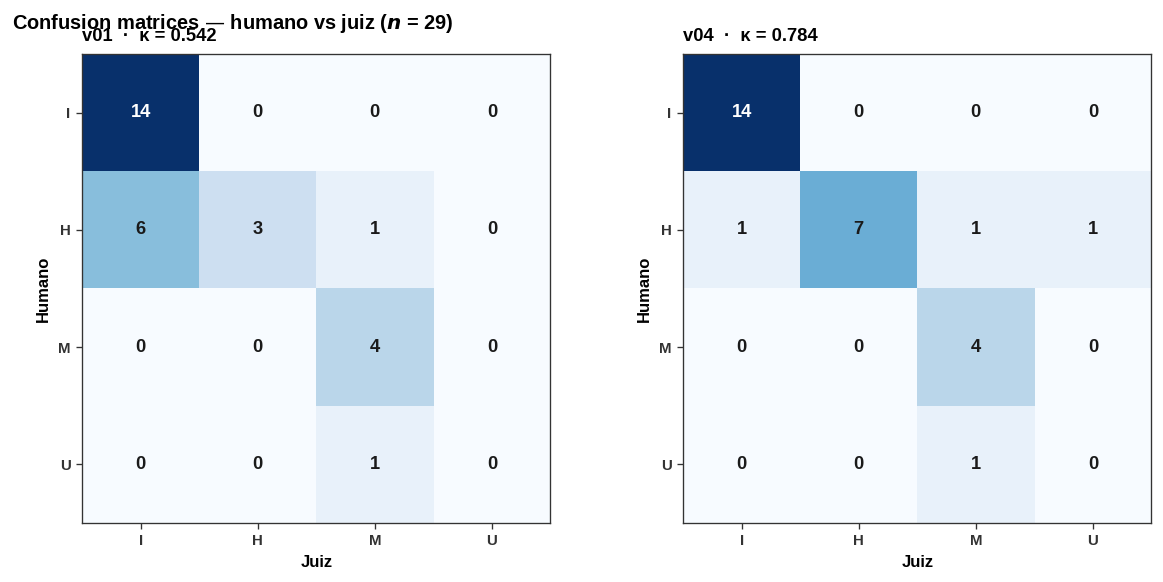

v01 — discordâncias: I↔H=6  ·  outras=2
v04 — discordâncias: I↔H=1  ·  outras=3


In [13]:
from sklearn.metrics import confusion_matrix

if len(common_29) == 0:
    print("Sem overlap entre v01/v04/humano — análise impossível.")
else:
    human_29 = common_29[HUMAN_EMAIL]
    v01_29   = common_29[V01_EMAIL]
    v04_29   = common_29[V04_EMAIL]

    matrix_v01 = confusion_matrix(human_29.tolist(), v01_29.tolist(), labels=_LABEL_ORDER)
    matrix_v04 = confusion_matrix(human_29.tolist(), v04_29.tolist(), labels=_LABEL_ORDER)
    kappa_v01 = cohen_kappa_score(human_29, v01_29)
    kappa_v04 = cohen_kappa_score(human_29, v04_29)

    with plt.rc_context(_PUBLICATION_RC):
        figure, axes = plt.subplots(1, 2, figsize=(10.0, 4.6), constrained_layout=True)
        for ax, matrix, kappa, title in [
            (axes[0], matrix_v01, kappa_v01, f"v01  ·  κ = {kappa_v01:.3f}"),
            (axes[1], matrix_v04, kappa_v04, f"v04  ·  κ = {kappa_v04:.3f}"),
        ]:
            vmax = max(1, max(matrix_v01.max(), matrix_v04.max()))
            image = ax.imshow(matrix, cmap="Blues", vmin=0, vmax=vmax)
            ax.set_xticks(range(len(_LABEL_ORDER)))
            ax.set_yticks(range(len(_LABEL_ORDER)))
            ax.set_xticklabels(_LABEL_ORDER)
            ax.set_yticklabels(_LABEL_ORDER)
            ax.set_xlabel("Juiz")
            ax.set_ylabel("Humano")
            ax.set_title(title, loc="left", pad=8)
            threshold = vmax / 2
            for i in range(matrix.shape[0]):
                for j in range(matrix.shape[1]):
                    value = matrix[i, j]
                    color = "white" if value > threshold else "#1a1a1a"
                    ax.text(j, i, str(value), ha="center", va="center",
                            color=color, fontsize=11, fontweight="bold")
        figure.suptitle(f"Confusion matrices — humano vs juiz ($\\mathit{{n}}$ = {len(common_29)})",
                        ha="left", x=0.0, y=1.02, fontweight="bold")
        plt.show()

    # Quantificação da hipótese "v04 colapsa pra I↔H"
    def off_diagonal_breakdown(matrix):
        adjacent = matrix[0, 1] + matrix[1, 0]  # I↔H
        far = matrix.sum() - matrix.trace() - adjacent
        return adjacent, far
    a_v01, f_v01 = off_diagonal_breakdown(matrix_v01)
    a_v04, f_v04 = off_diagonal_breakdown(matrix_v04)
    print(f"v01 — discordâncias: I↔H={a_v01}  ·  outras={f_v01}")
    print(f"v04 — discordâncias: I↔H={a_v04}  ·  outras={f_v04}")

### Sync post-hoc — puxar annotations do post-hoc user do LS

Roda esta cell **depois** de você terminar de classificar os 30 pares como `marcelo_post_hoc@human.eval` no LS UI. Pega as 30 annotations novas e grava em `evaluation_labels` com `annotator='marcelo_post_hoc@human.eval'`.

In [14]:
import importlib
from managers import evaluation_output_manager
from database.experiment_log import upsert_evaluation_labels
importlib.reload(evaluation_output_manager)

tasks = client.list_tasks_with_annotations(PROJECT_ID)
rows = evaluation_output_manager.collect_labels_from_tasks(tasks)
post_hoc_rows = [r for r in rows if r["annotator"] == "marcelo_post_hoc@human.eval"]
synced = upsert_evaluation_labels(post_hoc_rows) if post_hoc_rows else 0
print(f"{synced} rótulos do post-hoc sincronizados em evaluation_labels.")

30 rótulos do post-hoc sincronizados em evaluation_labels.


### Tabela 2 — Validação de generalização (κ_post_hoc) sobre 30 pares independentes

O κ_post_hoc é a métrica **headline de generalização** — medida sobre 30 pares que **não foram usados na iteração do prompt**. Comparada com κ_calibração (29 pares do piloto, expostos durante v01→v04), responde a pergunta: "o juiz funciona em dados novos com a mesma qualidade?"

- **κ_calibração** ≈ esperado em torno de 0.78 (medido sobre piloto)
- **κ_post_hoc** = número-tese de generalização
- **κ_combined** = descritivo, todos os 59 pares com label humano (não use como métrica primária)

In [15]:
import numpy as np
from sklearn.metrics import cohen_kappa_score

HUMAN_EMAIL    = "marcelogabrielfechine@gmail.com"
POST_HOC_EMAIL = "marcelo_post_hoc@human.eval"
V04_EMAIL      = "openai_gpt-4.1-v04@llm.eval"

with open_analytical_connection() as connection:
    df = pd.read_sql(
        """
        SELECT smell_occurrence_id, annotator, label
        FROM evaluation_labels
        WHERE annotator IN (%s, %s, %s)
        """,
        connection,
        params=(HUMAN_EMAIL, POST_HOC_EMAIL, V04_EMAIL),
    )

pivot = df.pivot_table(
    index="smell_occurrence_id",
    columns="annotator", values="label", aggfunc="first",
)

pilot_subset    = pivot.dropna(subset=[HUMAN_EMAIL, V04_EMAIL])
post_hoc_subset = pivot.dropna(subset=[POST_HOC_EMAIL, V04_EMAIL])

# "Any human" combina label do piloto e do post-hoc (cada par tem só um humano por construção)
pivot["__any_human"] = pivot[HUMAN_EMAIL].combine_first(pivot[POST_HOC_EMAIL])
combined_subset = pivot.dropna(subset=["__any_human", V04_EMAIL])

def bootstrap_kappa(a, b, n_iters=1000, seed=42):
    a_arr = np.asarray(a); b_arr = np.asarray(b)
    rng = np.random.default_rng(seed)
    samples = []
    for _ in range(n_iters):
        idx = rng.integers(0, len(a_arr), size=len(a_arr))
        try:
            samples.append(cohen_kappa_score(a_arr[idx], b_arr[idx]))
        except ValueError:
            continue
    samples = np.asarray(samples)
    return {
        "kappa_point":     cohen_kappa_score(a_arr, b_arr),
        "kappa_boot_mean": float(samples.mean()),
        "ci_low":          float(np.percentile(samples, 2.5)),
        "ci_high":         float(np.percentile(samples, 97.5)),
        "bootstrap_std":   float(samples.std()),
    }

rows = []
for label_text, subset, human_col in [
    ("κ_calibração — v04 × humano piloto", pilot_subset,    HUMAN_EMAIL),
    ("κ_post_hoc   — v04 × humano post-hoc (validação independente)", post_hoc_subset, POST_HOC_EMAIL),
    ("κ_combined   — v04 × qualquer humano (descritivo)", combined_subset, "__any_human"),
]:
    if len(subset) < 2:
        print(f"  ⚠ {label_text}: n={len(subset)} insuficiente, pulando")
        continue
    stats = bootstrap_kappa(subset[human_col].tolist(), subset[V04_EMAIL].tolist())
    rows.append({
        "métrica":      label_text,
        "n":            len(subset),
        "κ":            round(stats["kappa_point"], 3),
        "κ_boot_mean":  round(stats["kappa_boot_mean"], 3),
        "CI_95_low":    round(stats["ci_low"], 3),
        "CI_95_high":   round(stats["ci_high"], 3),
        "boot_std":     round(stats["bootstrap_std"], 3),
    })

results_df = pd.DataFrame(rows)
results_df

/tmp/ipykernel_553740/495093729.py:9: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(


,métrica,n,κ,κ_boot_mean,CI_95_low,CI_95_high,boot_std
0,κ_calibração — v04 × humano piloto,30,0.788,0.788,0.597,0.947,0.095
1,κ_post_hoc — v04 × humano post-hoc (validaçã...,30,0.689,0.688,0.472,0.894,0.106
2,κ_combined — v04 × qualquer humano (descritivo),60,0.739,0.743,0.600,0.870,0.069


### Figura 2 — Matriz de confusão do juiz v04 contra anotação humana (n=59)

Diagonal = concordância. Off-diagonal mostra onde estão as discordâncias do juiz em relação ao humano. Pattern concentrado na fronteira I↔H (categorias positivas adjacentes) indica ruído soft de boundary; discordâncias distantes (I↔M, H↔U etc.) indicam erros mais sérios.

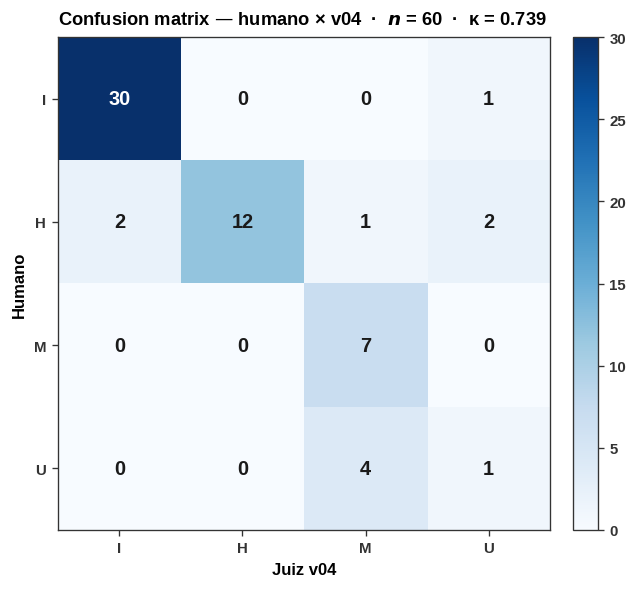

Concordância total (diagonal):     50/60 (83.3%)
Discordâncias adjacentes (I↔H):    2
Discordâncias distantes (outras):  8


In [16]:
from sklearn.metrics import confusion_matrix, cohen_kappa_score

if "combined_subset" not in dir():
    raise RuntimeError("Rode cell 32 primeiro — define combined_subset")

combined_human = combined_subset["__any_human"]
combined_v04   = combined_subset[V04_EMAIL]

matrix = confusion_matrix(combined_human.tolist(), combined_v04.tolist(), labels=_LABEL_ORDER)
kappa  = cohen_kappa_score(combined_human, combined_v04)
n_obs  = len(combined_subset)

with plt.rc_context(_PUBLICATION_RC):
    figure, ax = plt.subplots(figsize=(5.5, 4.8), constrained_layout=True)
    vmax = max(1, matrix.max())
    image = ax.imshow(matrix, cmap="Blues", vmin=0, vmax=vmax)
    ax.set_xticks(range(len(_LABEL_ORDER)))
    ax.set_yticks(range(len(_LABEL_ORDER)))
    ax.set_xticklabels(_LABEL_ORDER)
    ax.set_yticklabels(_LABEL_ORDER)
    ax.set_xlabel("Juiz v04")
    ax.set_ylabel("Humano")
    ax.set_title(
        f"Confusion matrix — humano × v04  ·  $\\mathit{{n}}$ = {n_obs}  ·  κ = {kappa:.3f}",
        loc="left", pad=8,
    )
    threshold = vmax / 2
    for i in range(matrix.shape[0]):
        for j in range(matrix.shape[1]):
            value = matrix[i, j]
            color = "white" if value > threshold else "#1a1a1a"
            ax.text(j, i, str(value), ha="center", va="center",
                    color=color, fontsize=12, fontweight="bold")
    figure.colorbar(image, ax=ax, fraction=0.046, pad=0.04)
    plt.show()

def adjacency_breakdown(m):
    adj = m[0, 1] + m[1, 0]
    far = m.sum() - m.trace() - adj
    return adj, far

adj, far = adjacency_breakdown(matrix)
agreement = matrix.trace()
total     = matrix.sum()
print(f"Concordância total (diagonal):     {agreement}/{total} ({100*agreement/total:.1f}%)")
print(f"Discordâncias adjacentes (I↔H):    {adj}")
print(f"Discordâncias distantes (outras):  {far}")

## 13. Resultados — distribuição IHMU sobre todos os pares avaliados

Depois de validar o juiz contra o humano (Seção 11), aplicamos o prompt v04 a todos os pares elegíveis em `llm_prompt_results` (n=438 anotados, 6 excluídos por TPM cap em arquivos >40k chars). A distribuição agregada estima a qualidade dos code reviews gerados pelo gpt-4.1 sobre o MLCQ benchmark.

### Figura 3 — Distribuição IHMU agregada (I/H/M/U)

Barra empilhada horizontal: fração de cada label sobre o total. Cada segmento é rotulado dentro da própria barra (o segmento fino **U**/Uncertain em duas linhas), de modo que os quatro rótulos ficam visíveis e somam 100 % (percentuais inteiros por arredondamento de maior resto).

Scores derivados (Yu et al.) — reportados fora desta figura (texto/tabela):

- **I-Score** = I / total · *higher is better*
- **IH-Score** = (I+H) / total · *higher is better*
- **M-Score** = M / total · *lower is better*

> **Nota de figura (paper).** O modelo/prompt vão na *caption* (convenção de paper), não embutidos na imagem. O `n` e os três scores também saíram da figura — ela mostra apenas a distribuição IHMU.
>
> **Caption sugerida:** *Aggregated IHMU label distribution over all review pairs judged by the LLM judge (gpt-4.1, prompt v04; n = 438). Segment widths are each label's share of the total, each labelled in place (the thin U/Uncertain segment on two lines) so the four categories account for the full 100 %.*

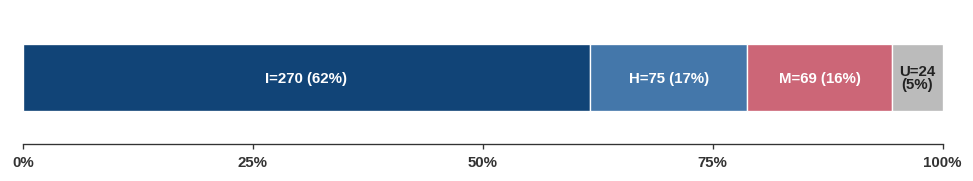

In [27]:
def plot_ihmu_distribution(labels_series):
    counts = labels_series.value_counts().reindex(_LABEL_ORDER, fill_value=0)
    total = int(counts.sum())
    if total == 0:
        print("Sem rótulos.")
        return

    percentages = counts / total * 100
    # Integer label percentages via largest-remainder rounding so the printed values
    # sum to exactly 100 % (segment *widths* keep the true float values — geometry stays exact).
    present = [label for label in _LABEL_ORDER if counts[label] > 0]
    floors = {label: int(percentages[label] // 1) for label in present}
    deficit = 100 - sum(floors.values())
    for label in sorted(present, key=lambda k: percentages[k] - floors[k], reverse=True)[:deficit]:
        floors[label] += 1
    label_pct = floors  # {label: int %}, guaranteed to sum to 100

    inline_label_min_width = 6

    with plt.rc_context(_PUBLICATION_RC):
        figure, axes_bar = plt.subplots(figsize=(8.0, 1.4), constrained_layout=True)

        left = 0.0
        for label in _LABEL_ORDER:
            width = float(percentages[label])
            if width <= 0:
                continue
            axes_bar.barh([0], [width], left=left, height=0.55,
                color=_LABEL_COLORS[label], edgecolor="white", linewidth=0.8)
            center = left + width / 2
            # U's fill is a light grey, so it takes dark ink; the coloured segments take white.
            text_color = "white" if label != "U" else "#222222"
            if width >= inline_label_min_width:
                # Wide enough for a one-line label.
                axes_bar.text(center, 0, f"{label}={int(counts[label])} ({label_pct[label]}%)",
                    ha="center", va="center", color=text_color, fontsize=9, fontweight="bold")
            else:
                # Too thin for one line — stack count over percent so the label still fits
                # *inside* the sliver (every segment stays named; the bar reads as a full 100 %).
                axes_bar.text(center, 0, f"{label}={int(counts[label])}\n({label_pct[label]}%)",
                    ha="center", va="center", color=text_color, fontsize=9,
                    fontweight="bold", linespacing=0.9)
            left += width

        axes_bar.set_xlim(0, 100); axes_bar.set_ylim(-0.55, 0.55); axes_bar.set_yticks([])
        axes_bar.set_xticks([0, 25, 50, 75, 100])
        axes_bar.set_xticklabels(["0%", "25%", "50%", "75%", "100%"])
        for spine in ("top", "right", "left"):
            axes_bar.spines[spine].set_visible(False)
        axes_bar.tick_params(axis="x", length=3)
        plt.show()


plot_ihmu_distribution(judge_labels_df["label"])

### Figura 4 — Distribuição IHMU por smell-alvo (+ I-Score, IH-Score, M-Score)

Uma barra empilhada por categoria de smell, ordenada por fração de I (decrescente). Mostra heterogeneidade: onde o juiz é mais instrumental, onde concentra M (review enganoso), onde fica U (incerto). Categorias com <3 rótulos são omitidas.

Os três scores da Figura 3 (I-Score, IH-Score, M-Score) aparecem anotados à direita de cada barra, com o mesmo código de cor. Eles são derivados da própria quebra empilhada — `I-Score = %I`, `IH-Score = %(I+H)`, `M-Score = %M` — então a figura carrega distribuição e scores numa única leitura. Isso torna a Figura 5 (barras agrupadas) redundante.

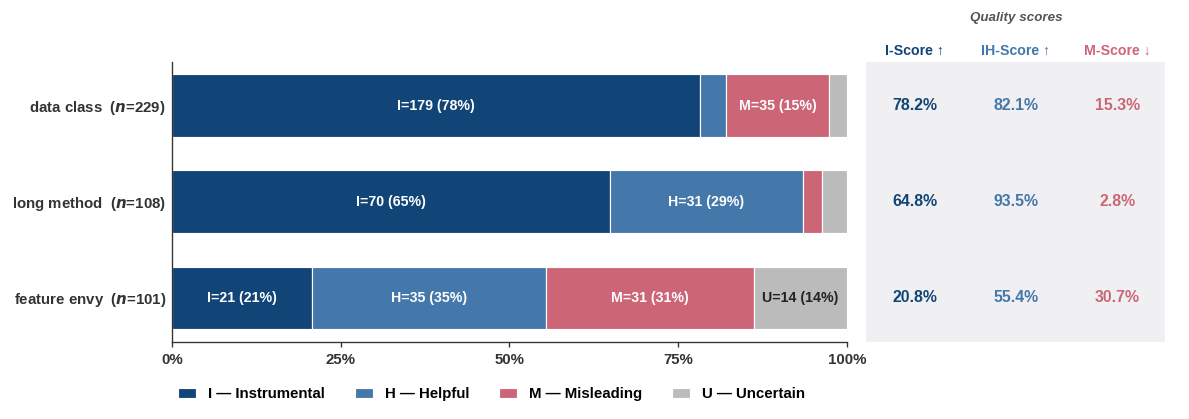

In [26]:
def plot_ihmu_by_smell(df, title=None, min_labels=3, show_scores=True):
    counts_by_smell = (
        df.groupby(["oracle_smell", "label"]).size()
          .unstack(fill_value=0)
          .reindex(columns=_LABEL_ORDER, fill_value=0)
    )
    counts_by_smell["total"] = counts_by_smell[_LABEL_ORDER].sum(axis=1)
    eligible = counts_by_smell[counts_by_smell["total"] >= min_labels]
    skipped = len(counts_by_smell) - len(eligible)
    if skipped:
        print(f"{skipped} smell(s) com < {min_labels} rótulos — omitidos.")
    if eligible.empty:
        print(f"Nenhum smell atinge {min_labels} rótulos.")
        return

    percentages = (eligible[_LABEL_ORDER].div(eligible["total"], axis=0) * 100).sort_values("I", ascending=True)
    counts_ordered = eligible[_LABEL_ORDER].reindex(percentages.index)
    smell_totals = eligible["total"].reindex(percentages.index)
    inline_label_min_width = 8

    # Painel de "Quality scores" à direita — métricas de qualidade (Yu et al.), distintas da
    # composição da barra. arrow = polaridade (higher/lower is better).
    # I-Score = %I · IH-Score = %(I+H) · M-Score = %M.
    score_cols = [
        ("I-Score",  "↑", percentages["I"],                    _LABEL_COLORS["I"], 110),
        ("IH-Score", "↑", percentages["I"] + percentages["H"], _LABEL_COLORS["H"], 125),
        ("M-Score",  "↓", percentages["M"],                    _LABEL_COLORS["M"], 140),
    ]
    panel_left, panel_right = 103, 147
    x_max = 149 if show_scores else 100
    fig_w = 9.8 if show_scores else 7.2

    with plt.rc_context(_PUBLICATION_RC):
        row_count = len(percentages)
        figure, axes = plt.subplots(
            figsize=(fig_w, max(2.8, 0.55 * row_count + 1.7)),
            constrained_layout=True,
        )
        if show_scores:
            axes.axvspan(panel_left, panel_right, color="#f0f0f2", zorder=0)
        left_offsets = pd.Series(0.0, index=percentages.index)
        for label in _LABEL_ORDER:
            axes.barh(percentages.index, percentages[label],
                left=left_offsets, height=0.65,
                color=_LABEL_COLORS[label], edgecolor="white", linewidth=0.7,
                label=f"{label} — {_FULL_LABEL_NAMES[label]}")
            for row_index, smell_name in enumerate(percentages.index):
                width = float(percentages.loc[smell_name, label])
                if width < inline_label_min_width:
                    continue
                count = int(counts_ordered.loc[smell_name, label])
                text_color = "white" if label != "U" else "#222222"
                axes.text(left_offsets[smell_name] + width / 2, row_index,
                    f"{label}={count} ({width:.0f}%)",
                    ha="center", va="center", color=text_color, fontsize=8.5, fontweight="bold")
            left_offsets = left_offsets + percentages[label]

        if show_scores:
            axes.text((panel_left + panel_right) / 2, (row_count - 1) + 0.85, "Quality scores",
                ha="center", va="bottom", color="#555555", fontsize=8, fontstyle="italic")
            for header, arrow, series, color, x_pos in score_cols:
                axes.text(x_pos, (row_count - 1) + 0.5, f"{header} {arrow}",
                    ha="center", va="bottom", color=color, fontsize=8.5, fontweight="bold")
                for row_index, smell_name in enumerate(percentages.index):
                    axes.text(x_pos, row_index, f"{series.loc[smell_name]:.1f}%",
                        ha="center", va="center", color=color, fontsize=9.5, fontweight="bold")

        axes.set_yticks(range(row_count))
        axes.set_yticklabels([f"{name}  ($\\mathit{{n}}$={smell_totals[name]})" for name in percentages.index])
        axes.set_xlim(0, x_max); axes.set_xticks([0, 25, 50, 75, 100])
        axes.set_xticklabels(["0%", "25%", "50%", "75%", "100%"])
        axes.spines["bottom"].set_bounds(0, 100)  # eixo real só até 100%; scores ficam na margem
        for spine in ("top", "right"):
            axes.spines[spine].set_visible(False)
        axes.tick_params(axis="x", length=3); axes.tick_params(axis="y", length=0)
        axes.legend(loc="upper left", bbox_to_anchor=(0.0, -0.14),
            ncols=4, frameon=False, handlelength=1.2, fontsize=9, borderaxespad=0)
        plt.show()


plot_ihmu_by_smell(judge_labels_df, show_scores=True)

### Figura 4 (variante sem scores)

Mesma distribuição IHMU por smell, sem o painel de *Quality scores* — só a composição I/H/M/U. Útil quando a discussão dos scores fica no texto/legenda e a figura precisa ficar mais enxuta.

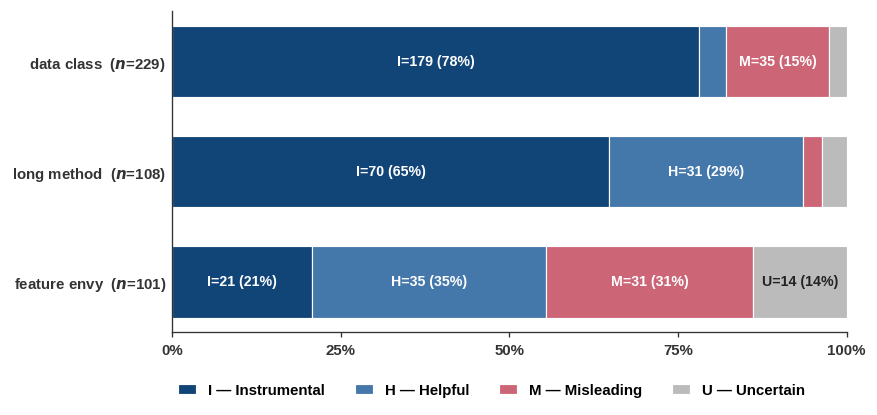

In [24]:
plot_ihmu_by_smell(judge_labels_df, show_scores=False)

### Figura 5 — I-Score, IH-Score e M-Score por smell  ⚠ SUPERSEDED pela Figura 4

> **Nota:** desde que os três scores passaram a ser anotados na Figura 4 (à direita de cada barra), esta figura de barras agrupadas ficou redundante e foi aposentada do paper. O código é mantido apenas para consulta/apêndice. As barras agrupadas confundem porque (1) IH-Score contém I-Score (métricas aninhadas plotadas como independentes) e (2) misturam polaridade ("higher is better" com "lower is better").

Gráfico de barras agrupadas comparando as três métricas-chave (Yu et al.) por categoria de smell:

- **I-Score** = I / total · *higher is better*
- **IH-Score** = (I+H) / total · *higher is better*
- **M-Score** = M / total · *lower is better*

Responde diretamente a RQ1 (*o tipo de smell afeta a qualidade da review?*): smells com I-Score mais alto e M-Score mais baixo são "mais fáceis" para o LLM-under-test.

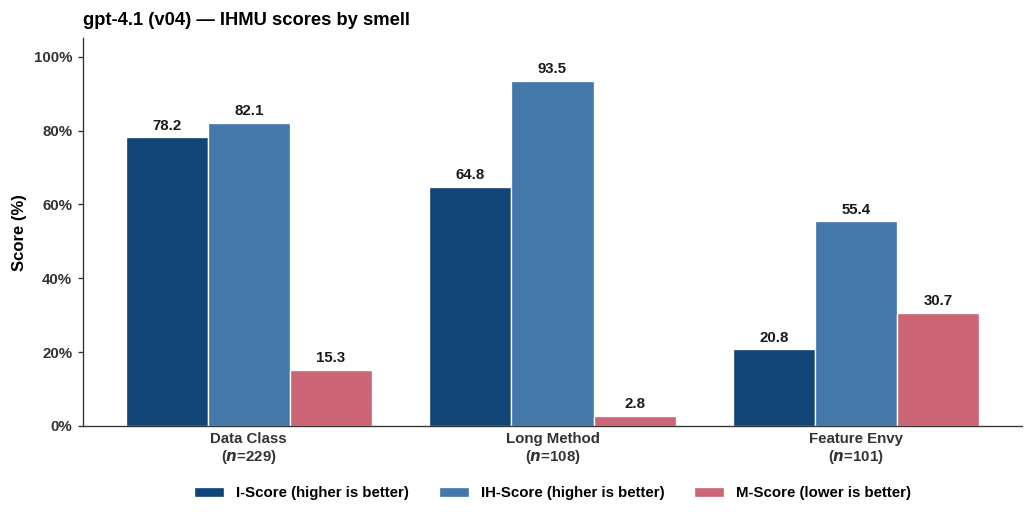


Tabela:


,smell,n,I-Score,IH-Score,M-Score
0,Data Class,229,78.2,82.1,15.3
1,Long Method,108,64.8,93.5,2.8
2,Feature Envy,101,20.8,55.4,30.7


In [21]:
import numpy as np

# Calcula scores por smell a partir de judge_labels_df
counts_by_smell = (
    judge_labels_df.groupby(["oracle_smell", "label"]).size()
      .unstack(fill_value=0)
      .reindex(columns=_LABEL_ORDER, fill_value=0)
)
counts_by_smell["total"] = counts_by_smell[_LABEL_ORDER].sum(axis=1)
eligible = counts_by_smell[counts_by_smell["total"] >= 3]

if eligible.empty:
    print("Nenhum smell com dados suficientes.")
else:
    scores_data = []
    for smell_name in eligible.index:
        c = eligible.loc[smell_name]
        total = c["total"]
        scores_data.append({
            "smell":    smell_name.title(),
            "n":        int(total),
            "I-Score":  100 * c["I"] / total,
            "IH-Score": 100 * (c["I"] + c["H"]) / total,
            "M-Score":  100 * c["M"] / total,
        })

    scores_df = pd.DataFrame(scores_data).sort_values("I-Score", ascending=False)
    smells = scores_df["smell"].tolist()
    n_smells = len(smells)

    score_specs = [
        ("I-Score",  _LABEL_COLORS["I"], "higher is better"),
        ("IH-Score", _LABEL_COLORS["H"], "higher is better"),
        ("M-Score",  _LABEL_COLORS["M"], "lower is better"),
    ]
    x = np.arange(n_smells)
    bar_width = 0.27

    with plt.rc_context(_PUBLICATION_RC):
        figure, axes = plt.subplots(figsize=(8.5, 4.2), constrained_layout=True)
        for idx, (name, color, _qual) in enumerate(score_specs):
            offsets = (idx - 1) * bar_width
            values  = scores_df[name].values
            bars = axes.bar(x + offsets, values, bar_width,
                color=color, edgecolor="white", linewidth=0.8, label=name)
            for xi, value in zip(x + offsets, values):
                axes.text(xi, value + 1.2, f"{value:.1f}", ha="center", va="bottom",
                    fontsize=9, fontweight="bold", color="#1a1a1a")

        axes.set_xticks(x)
        axes.set_xticklabels([f"{s}\n($\\mathit{{n}}$={n})" for s, n in zip(smells, scores_df["n"])])
        axes.set_ylim(0, max(105, scores_df[["I-Score", "IH-Score"]].max().max() + 8))
        axes.set_ylabel("Score (%)")
        axes.set_title(f"{JUDGE_DISPLAY_NAME} — IHMU scores by smell", loc="left", pad=8)
        for spine in ("top", "right"):
            axes.spines[spine].set_visible(False)
        axes.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{int(v)}%"))
        axes.tick_params(axis="x", length=0); axes.tick_params(axis="y", length=3)

        # Legenda com indicação de "higher/lower is better"
        handles, labels_ = axes.get_legend_handles_labels()
        legend_labels = [f"{name} ({qual})" for name, _color, qual in score_specs]
        axes.legend(handles, legend_labels,
            loc="upper center", bbox_to_anchor=(0.5, -0.12),
            ncols=3, frameon=False, fontsize=9)
        plt.show()

    print("\nTabela:")
    display_df = scores_df.copy()
    for col in ["I-Score", "IH-Score", "M-Score"]:
        display_df[col] = display_df[col].round(1)
    display_df.reset_index(drop=True, inplace=True)
    display(display_df)

### Figura 6 — Padrões de falha por smell (Misleading reviews)

Network bipartite weighted: cada padrão de falha é um nó (lado esquerdo), conectado aos smells (lado direito, Data Class no topo e Feature Envy embaixo). Espessura da aresta proporcional à contagem de casos. Padrões transversais (LM-bias) aparecem com ambas as cores; padrões smell-específicos têm apenas uma cor.

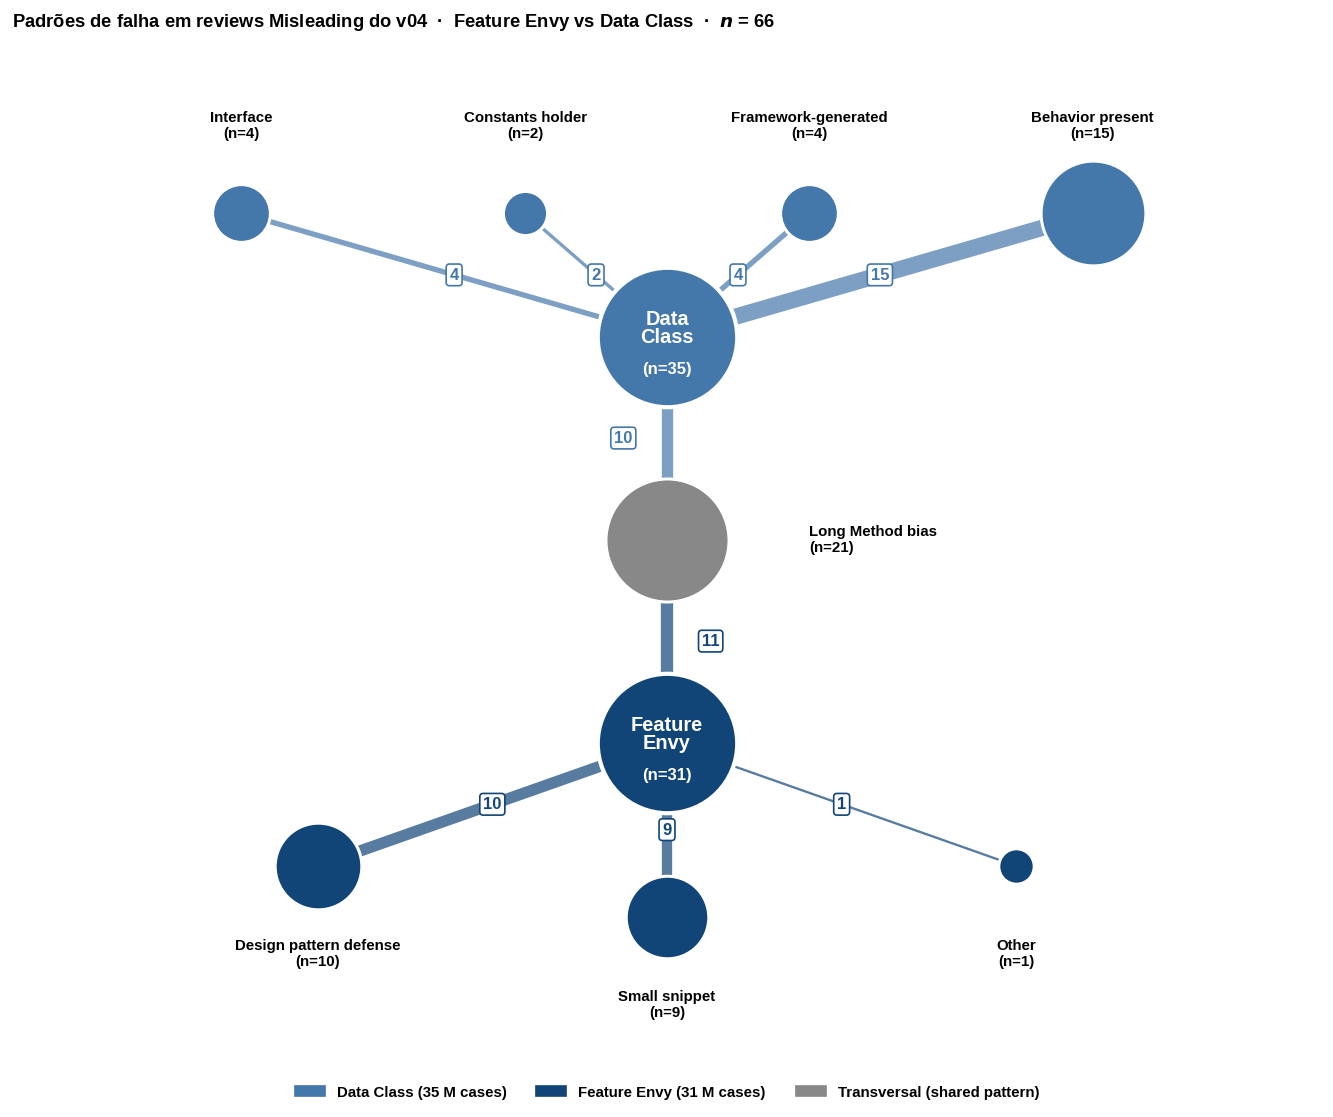

In [29]:
import json
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from collections import Counter

with open(_project_root / "results/v04_misleading_categorization.json") as f:
    coded = json.load(f)

counts = Counter((c["smell"], c["category"]) for c in coded)
smell_totals = Counter(c["smell"] for c in coded)
category_totals = Counter(c["category"] for c in coded)

PALETTE = {
    "data class":    "#4477AA",  # mesma cor de IH-Score
    "feature envy":  "#114477",  # mesma cor de I-Score
    "transversal":   "#888888",
}

smell_positions = {
    "data class":   (0.50, 0.78),
    "feature envy": (0.50, 0.22),
}
DC_PATTERNS = ["Interface", "Constants holder", "Framework-generated", "Behavior present"]
dc_xs = [0.11, 0.37, 0.63, 0.89]
cat_positions = {cat: (x, 0.95) for cat, x in zip(DC_PATTERNS, dc_xs)}
cat_positions["Design pattern defense"] = (0.18, 0.05)
cat_positions["Small snippet"]          = (0.50, -0.02)
cat_positions["Other"]                  = (0.82, 0.05)
cat_positions["Long Method bias"] = (0.50, 0.50)

def node_size(n): return 200 + 250 * n
def edge_width(n): return 0.8 + 0.6 * n

LABEL_GAP_VERTICAL   = 0.10
LABEL_GAP_HORIZONTAL = 0.13


def plot_misleading_failure_network(show_header=True):
    """Rede bipartite dos padrões de falha (Fig. 6). show_header=False omite o
    título embutido — o modelo/prompt/n vão para a caption (convenção de paper)."""
    with plt.rc_context(_PUBLICATION_RC):
        fig, ax = plt.subplots(figsize=(11, 9.2), constrained_layout=True)
        for (smell, cat), n in counts.items():
            x0, y0 = cat_positions[cat]
            x1, y1 = smell_positions[smell]
            color = PALETTE[smell]
            ax.plot([x0, x1], [y0, y1], color=color, linewidth=edge_width(n), alpha=0.7, zorder=1)
            mx, my = (x0 + x1) / 2, (y0 + y1) / 2
            offset_x = 0.04 if (cat == "Long Method bias" and smell == "feature envy") else (-0.04 if cat == "Long Method bias" else 0.0)
            ax.text(mx + offset_x, my, str(n), fontsize=10, fontweight="bold", color=color,
                    ha="center", va="center",
                    bbox=dict(boxstyle="round,pad=0.2", facecolor="white",
                              edgecolor=color, linewidth=1.0), zorder=4)
        for smell, (x, y) in smell_positions.items():
            total = smell_totals[smell]
            ax.scatter(x, y, s=7000, c=PALETTE[smell], edgecolors="white", linewidths=2.5, zorder=2)
            label = "Data\nClass" if smell == "data class" else "Feature\nEnvy"
            ax.text(x, y + 0.012, label, ha="center", va="center", fontsize=12, fontweight="bold",
                    color="white", zorder=3, linespacing=0.95)
            ax.text(x, y - 0.045, f"(n={total})", ha="center", va="center", fontsize=10, fontweight="bold",
                    color="white", zorder=3)
        for cat, (x, y) in cat_positions.items():
            total = category_totals[cat]
            size = node_size(total)
            is_transversal = sum(1 for s in smell_positions if counts.get((s, cat), 0) > 0) > 1
            if is_transversal:
                color = PALETTE["transversal"]
            else:
                dominant = max(smell_positions, key=lambda s: counts.get((s, cat), 0))
                color = PALETTE[dominant]
            ax.scatter(x, y, s=size, c=color, edgecolors="white", linewidths=1.8, zorder=2)
            if y > 0.7:
                ax.text(x, y + LABEL_GAP_VERTICAL, f"{cat}\n(n={total})",
                        ha="center", va="bottom", fontsize=9, fontweight="bold")
            elif y < 0.3:
                ax.text(x, y - LABEL_GAP_VERTICAL, f"{cat}\n(n={total})",
                        ha="center", va="top", fontsize=9, fontweight="bold")
            else:
                ax.text(x + LABEL_GAP_HORIZONTAL, y, f"{cat}\n(n={total})",
                        ha="left", va="center", fontsize=9, fontweight="bold")
        ax.set_xlim(-0.10, 1.10); ax.set_ylim(-0.22, 1.18)
        ax.set_xticks([]); ax.set_yticks([])
        for spine in ax.spines.values():
            spine.set_visible(False)
        if show_header:
            ax.set_title(
                "Padrões de falha em reviews Misleading do v04  ·  Feature Envy vs Data Class  ·  $\\mathit{n}$ = 66",
                loc="left", pad=12,
            )
        legend_handles = [
            mpatches.Patch(color=PALETTE["data class"],   label=f"Data Class ({smell_totals['data class']} M cases)"),
            mpatches.Patch(color=PALETTE["feature envy"], label=f"Feature Envy ({smell_totals['feature envy']} M cases)"),
            mpatches.Patch(color=PALETTE["transversal"],  label="Transversal (shared pattern)"),
        ]
        ax.legend(handles=legend_handles, loc="lower center",
                  bbox_to_anchor=(0.5, -0.05), ncol=3, frameon=False, fontsize=9)
        plt.show()


plot_misleading_failure_network(show_header=True)

### Figura 6 (variante sem header)

Mesma rede bipartite de padrões de falha, sem o título embutido na imagem — o modelo/prompt e o `n` vão na *caption* (convenção de paper). Legenda e rótulos dos nós permanecem.

> **Caption sugerida:** *Failure-pattern network for Misleading (M) reviews from the LLM judge (gpt-4.1, prompt v04; n = 66). Each failure pattern (node) links to the smell(s) it appears under — Data Class (top) and Feature Envy (bottom); edge thickness is proportional to case count. Transversal patterns (e.g. LM-bias) connect to both smells; smell-specific patterns to one.*

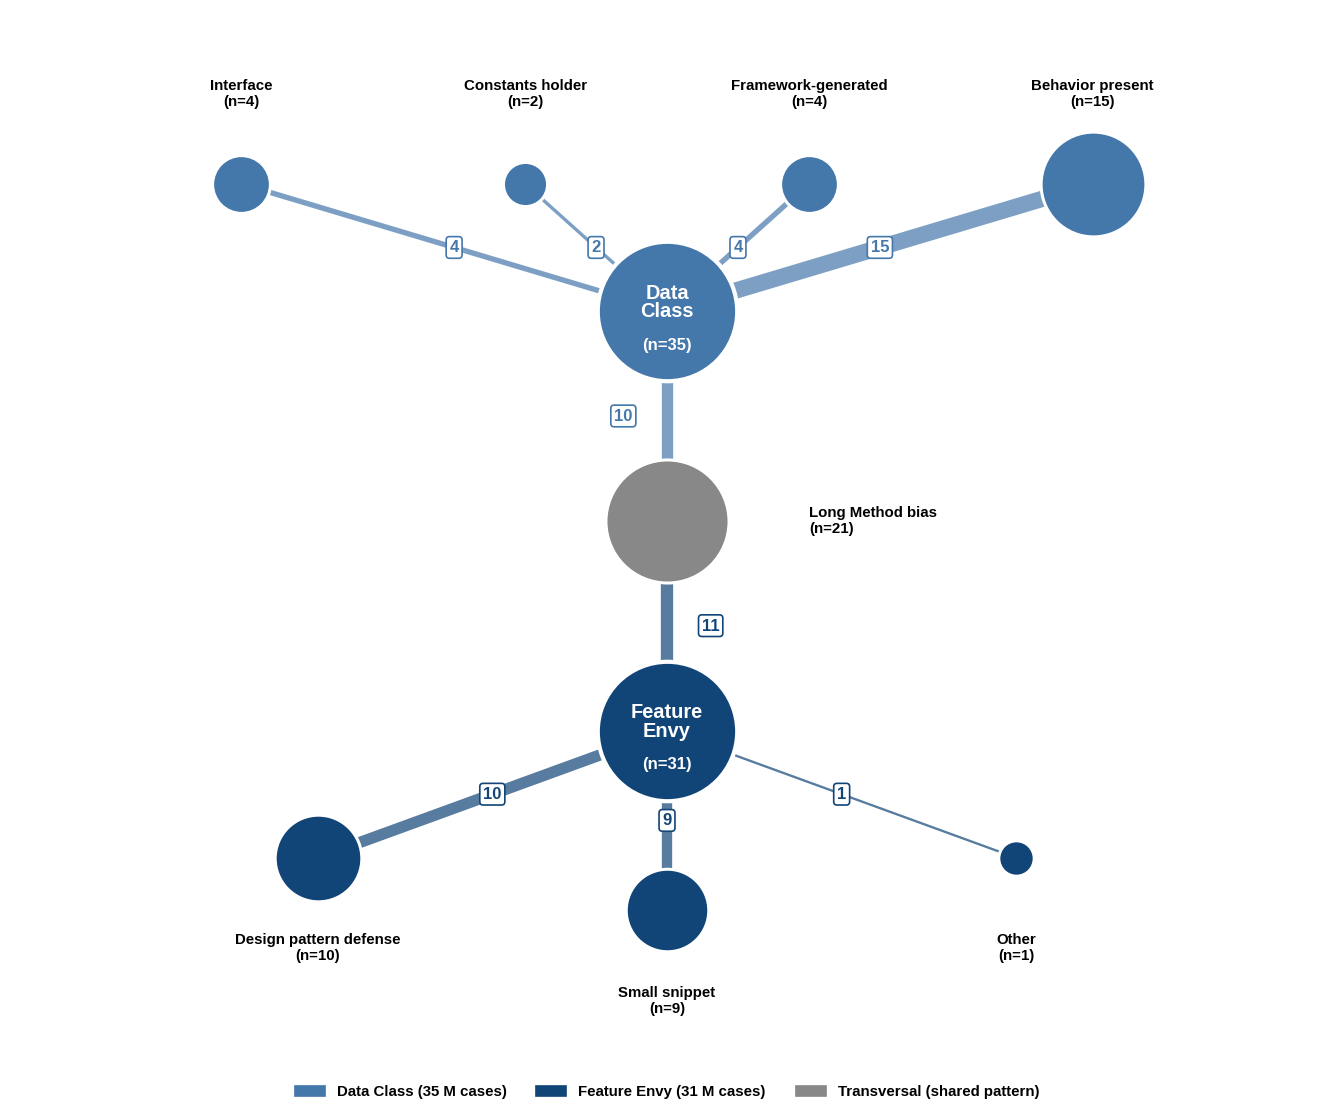

In [30]:
plot_misleading_failure_network(show_header=False)